# 02 - Instance Segmentation

Ejemplos para modelos `*-seg.pt`: lectura de poligonos, filtrado y ploteo directo de mascaras.


In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "vision").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 3 and (cwd.parents[2] / "vision").exists():
    PROJECT_ROOT = cwd.parents[2]
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_DIR = PROJECT_ROOT / "vision" / "yolo" / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE = (
    str(NOTEBOOK_DIR / "bus.jpg")
    if (NOTEBOOK_DIR / "bus.jpg").exists()
    else "https://ultralytics.com/images/bus.jpg"
)

from vision.yolo.infer import predict_image
from vision.yolo.plotting import (
    plot_segmentation_masks,
    plot_image_detections,
    plot_class_distribution,
)

MODEL = (
    str(NOTEBOOK_DIR / "yolo11n-seg.pt")
    if (NOTEBOOK_DIR / "yolo11n-seg.pt").exists()
    else "yolo11n-seg.pt"
)


In [ ]:
df = predict_image(MODEL, IMAGE, confidence=0.25, task="segment")
print(
    df[
        ["frame", "class_name", "confidence", "xmin", "ymin", "xmax", "ymax", "polygon"]
    ].head()
)


/home/juan/miniforge3/envs/ultralytics/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


   frame class_name  confidence        xmin        ymin        xmax  \
0      0        bus    0.898599   19.677492  230.010147  801.787109   
1      0     person    0.884889  670.144897  390.593109  809.551819   
2      0     person    0.862790   49.492699  398.129395  240.765015   
3      0     person    0.822238  222.645477  404.546387  346.057892   
4      0  stop sign    0.461499    0.114236  254.572876   31.958389   

         ymax                                            polygon  
0  744.141235  [[185.625, 232.875], [185.625, 237.9375], [183...  
1  875.301208  [[804.9375, 396.5625], [803.25, 398.25], [801....  
2  905.102112  [[101.25, 394.875], [101.25, 401.625], [99.562...  
3  859.875671  [[264.9375, 401.625], [264.9375, 408.375], [26...  
4  325.650879  [[3.375, 253.125], [3.375, 332.4375], [10.125,...  


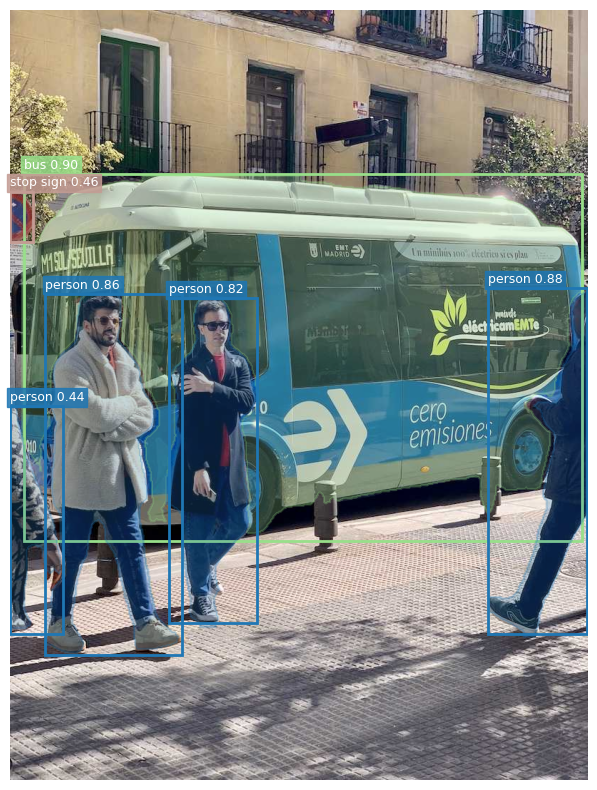

In [ ]:
# Plot directo de mascaras + cajas
plot_segmentation_masks(
    IMAGE,
    df,
    draw_boxes=True,
    confidence_threshold=0.25,
    save_to=OUTPUT_DIR / "02_segmentation_masks.png",
)


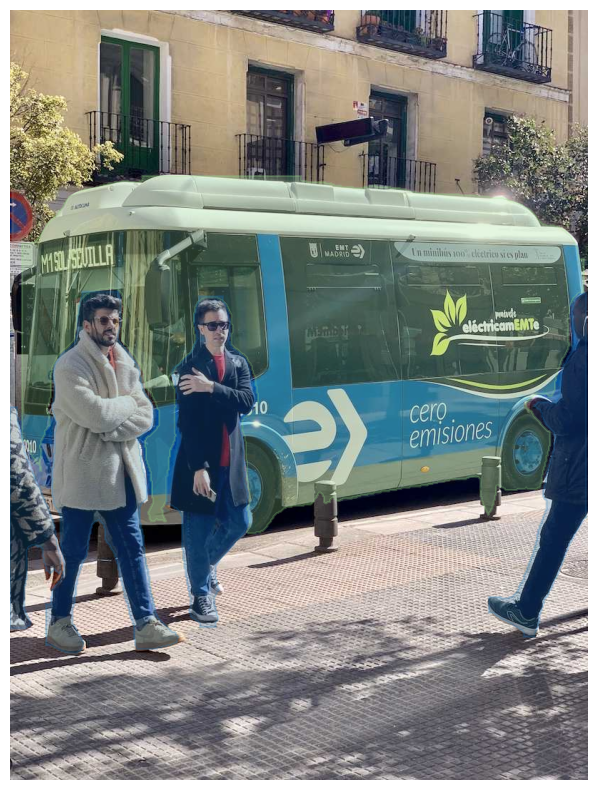

In [ ]:
# Solo poligonos, sin cajas
plot_segmentation_masks(
    IMAGE,
    df,
    draw_boxes=False,
    draw_labels=False,
    save_to=OUTPUT_DIR / "02_polygons_only.png",
)


In [ ]:
# Inspeccion de vertices por deteccion
with_polygons = df[df["polygon"].notna()].copy()
with_polygons["n_vertices"] = with_polygons["polygon"].apply(
    lambda p: len(p) if isinstance(p, list) else 0
)
print(with_polygons[["class_name", "confidence", "n_vertices"]].head())


  class_name  confidence  n_vertices
0        bus    0.898599         666
1     person    0.884889         233
2     person    0.862790         319
3     person    0.822238         210
4  stop sign    0.461499          23


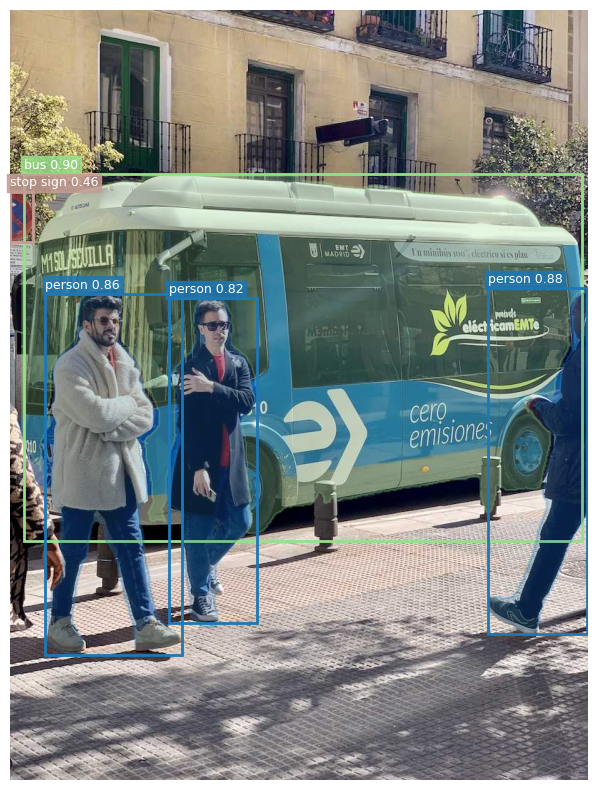

In [ ]:
# Filtrar una clase o una confianza antes del plot
filtered = df[df["confidence"].ge(0.45)]
plot_image_detections(
    IMAGE,
    filtered,
    draw_boxes=True,
    draw_polygons=True,
    draw_keypoints=False,
    save_to=OUTPUT_DIR / "02_filtered_segments.png",
)


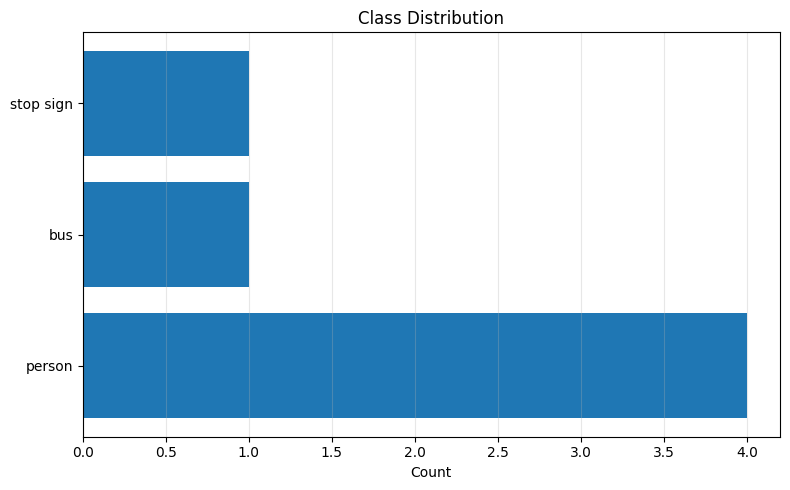

In [ ]:
plot_class_distribution(df, save_to=OUTPUT_DIR / "02_class_distribution.png")
